Biometrich Technologies and Behavioural Security
# **<center>Tutorial 6 - Multimodal biometric systems </center>**

In the past months, a big multinational technology company suffered a data breach from a group of hackers called 'Famous'. They stole nearly 3 million encrypted customer credit card records and login data for an undetermined number of user accounts.

After a complex and in-depth analysis, the source of the attack has been identified in a vulnerability in the biometric system, precisely in the old capacitive sensor that the company uses to identify his employees.

For these reasons, they ask you to make a study of possible solutions to this problem. Basically, the options are two:

*   To buy another type of sensor.
*   To enroll and use one additional finger for each employee.

Demonstrate to the company, with data (EER) and graphs (ROC curves), which is the best options in terms of accuracy, if they implement a multimodal system with old sensor and new solutions.

You can refer to the tutorial of fingerprint extraction for feature extraction, match score and error computing procedure.

##Step 0: Import libraries and define useful functions

In [ ]:
import time,glob
import os
import subprocess
import numpy as np
import cv2
from matplotlib import pyplot as plt
from IPython.display import clear_output
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
from IPython.display import HTML, display

def progress(value, max=100):
    return HTML("""
        <progress
            value='{value}'
            max='{max}',
            style='width: 100%'
        >
            {value}
        </progress>
    """.format(value=value, max=max))


ModuleNotFoundError: No module named 'pydrive'

##Sensor 1 (old one)

###Step 1: Download Dataset

This is the company employees dataset. Test the performance to define a benchmark.

In [ ]:
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

downloaded = drive.CreateFile({'id':"1C_dWwHf8KbhLqUiAfCNXqUSDIvZEGjxj"})
downloaded.GetContentFile('Sensor1.zip')
!unzip Sensor1
clear_output()
print('Done! Press the Refresh button if files are not visible.')

###Step 2: Feature Extraction

In [ ]:
path = '/content/Sensor1/' #Dataset path

samples = os.listdir(path)
!chmod 755 mindtct
print('Current Progress...')
out = display(progress(0, len(samples)-1), display_id=True)

for idx,fp in enumerate(samples):

  os.system('/content/mindtct -m1 -b '+ path + fp + ' ' + path + fp[0:4])
  out.update(progress(idx, len(samples)))

Current Progress...


###Step 3: Compute Match Score

In [ ]:
gallery=sorted(glob.glob(path+'*.xyt'))
idV = np.zeros((1,len(gallery)),dtype=int)
for i,el in enumerate(gallery):
  idV[0,i]=int(el[-8:-6])

listname='gallery.lis'
fileID = open(listname,'w');
for el in gallery:
    fileID.write(el+'\n')
fileID.close()

t = time.time()

scores1=np.zeros((len(gallery),len(gallery)),dtype=int)
legend1=np.ones((len(gallery),len(gallery)),dtype=int)*(-1)

!chmod 755 bozorth3
print('Performing matching...')
out = display(progress(0, len(gallery)-2), display_id=True)
for ii in range(len(gallery)-1):
  probe=gallery[ii]
  cID = int(probe[-8:-6])
  cmd = '/content/bozorth3 -m1 -A glines='+str(ii+2)+'-400 -p '+ probe +' -G /content/gallery.lis'
  output = subprocess.check_output(cmd, shell=True).decode("utf-8")
  scores1[ii,ii+1:] = np.array(output.splitlines(), dtype=int)
  legend1[ii,ii+1:] = (idV[0,ii+1:] == cID)*1
  out.update(progress(ii, len(gallery)-2))

elapsed = 'Time elapsed: %.2f s' %(time.time() - t)
print(elapsed)

Performing matching...


Time elapsed: 231.33 s


###Step 4: Compute Errors

In [ ]:
#Separate scores of genuines and impostors

genuines = scores1[legend1==1]
impostors = scores1[legend1==0]

#scores normalization in range [0,1]

mx = max(np.concatenate((genuines,impostors),axis=0))
mn = min(np.concatenate((genuines,impostors),axis=0))

genuines = (genuines - mn)/(mx-mn)
impostors = (impostors - mn)/(mx-mn)


In [ ]:
#Inizialize arrays for FRR and FAR storage
FRR=np.zeros((100,1))
FAR=np.zeros((100,1))

th=np.linspace(0,1,100);

for i,t in enumerate(th):

  count=len(np.argwhere(impostors>=t))
  FAR[i,0]=count/len(impostors)*100

  count=len(np.argwhere(genuines<t))
  FRR[i,0]=count/len(genuines)*100

In [ ]:
# EER Extimation

index = np.where(abs(FAR-FRR) == np.amin(abs(FAR-FRR)))
EER=(FAR[index]+FRR[index])/2
eer = 'The Equal Error Rate (EER) for Sensor 1 is %.2f %%' %(EER)
print(eer)

The Equal Error Rate (EER) for Sensor 1 is 14.23 %


<ipython-input-7-7404f4119828>:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  eer = 'The Equal Error Rate (EER) for Sensor 1 is %.2f %%' %(EER)


##Sensor 1 with different fingers

Repeat Steps 1-4 and choose a proper kind of fusion.



###Step 1.1 Download Dataset

In [ ]:
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

downloaded = drive.CreateFile({'id':"11w1eslOzjVgp9LIPS6JIuYNEjrC2_WfU"})   # replace the id with id of file you want to access
downloaded.GetContentFile('Sensor1_OF.zip')
!unzip Sensor1_OF
clear_output()
print('Done! Press the Refresh button if files are not visible.')


Done! Press the Refresh button if files are not visible.


###Step 1.2 Feature Extraction

In [ ]:
path = '/content/Sensor1_OF/' #Dataset path

samples = os.listdir(path)

print('Current Progress...')
out = display(progress(0, len(samples)), display_id=True)

for idx,fp in enumerate(samples):

  os.system('/content/mindtct -m1 -b '+ path + fp + ' ' + path + fp[0:4])
  out.update(progress(idx+1, len(samples)))

Current Progress...


### Step 1.3 Compute Match Score

In [ ]:
gallery=sorted(glob.glob(path+'*.xyt'))

listname='gallery.lis'
fileID = open(listname,'w');
for el in gallery:
    fileID.write(el+'\n')
fileID.close()

t = time.time()

scores1b=np.zeros((len(gallery),len(gallery)),dtype=int)


print('Performing matching...')
out = display(progress(0, len(gallery)-2), display_id=True)
for ii in range(len(gallery)-1):
  probe=gallery[ii]
  cID = int(probe[-8:-6])
  cmd = '/content/bozorth3 -m1 -A glines='+str(ii+2)+'-400 -p '+ probe +' -G /content/gallery.lis'
  output = subprocess.check_output(cmd, shell=True).decode("utf-8")
  scores1b[ii,ii+1:] = np.array(output.splitlines(), dtype=int)

  out.update(progress(ii+1, len(gallery)-2))

elapsed = 'Time elapsed: %.2f s' %(time.time() - t)
print(elapsed)

Performing matching...


Time elapsed: 335.60 s


###Step 1.4 Check Sensor 1 with different fingers performance

In [ ]:
#Separate scores of genuines and impostors

genuines1b = scores1b[legend1==1]
impostors1b = scores1b[legend1==0]

#scores normalization in range [0,1]

mx = max(np.concatenate((genuines1b,impostors1b),axis=0))
mn = min(np.concatenate((genuines1b,impostors1b),axis=0))

genuines1b = (genuines1b - mn)/(mx-mn)
impostors1b = (impostors1b - mn)/(mx-mn)

In [ ]:

FRR1b=np.zeros((100,1))
FAR1b=np.zeros((100,1))

for i,t in enumerate(th):

  count=len(np.argwhere(impostors1b>=t))
  FAR1b[i,0]=count/len(impostors1b)*100

  count=len(np.argwhere(genuines1b<t))
  FRR1b[i,0]=count/len(genuines1b)*100


# EER Extimation

index = np.where(abs(FAR1b-FRR1b) == np.amin(abs(FAR1b-FRR1b)))
EER1b=(FAR1b[index]+FRR1b[index])/2
eer = 'The Equal Error Rate (EER) for Sensor 1 with diff. fingers is %.2f %%' %(EER1b)
print(eer)

The Equal Error Rate (EER) for Sensor 1 with diff. fingers is 9.20 %


<ipython-input-12-c3a652359b56>:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  eer = 'The Equal Error Rate (EER) for Sensor 1 with diff. fingers is %.2f %%' %(EER1b)


##Multiple Units Fusion

We can choose a Decision Level Fusion with an AND rule.

###Decision Level

In [ ]:
FRR_dfmu=np.zeros((100,1))
FAR_dfmu=np.zeros((100,1))


for i,t in enumerate(th):

  count=np.count_nonzero(np.logical_and(impostors>=t,impostors1b>=t))
  FAR_dfmu[i,0]=count/len(impostors)*100

  count=np.count_nonzero(np.logical_and(genuines<t,genuines1b<t))
  FRR_dfmu[i,0]=count/len(genuines)*100


# EER Extimation

index = np.where(abs(FAR_dfmu-FRR_dfmu) == np.amin(abs(FAR_dfmu-FRR_dfmu)))
EER_dfmu=(FAR_dfmu[index]+FRR_dfmu[index])/2
eer = 'The Equal Error Rate (EER) in case of Decision Fusion and Multiple Units is %.2f %%' %(EER_dfmu)
print(eer)



The Equal Error Rate (EER) in case of Decision Fusion and Multiple Units is 1.89 %


<ipython-input-13-35c312e5bb9c>:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  eer = 'The Equal Error Rate (EER) in case of Decision Fusion and Multiple Units is %.2f %%' %(EER_dfmu)


## Sensor #2

Repeat Steps 1-4 and try different kind of fusion.

###Step 2.1 Download Dataset

In [ ]:
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

downloaded = drive.CreateFile({'id':"1hbn13sHBBQq5iRgIUndD-QbxPYaACawU"})
downloaded.GetContentFile('Sensor2.zip')
!unzip Sensor2
clear_output()
print('Done! Press the Refresh button if files are not visible.')

Done! Press the Refresh button if files are not visible.


###Step 2.2 Feature Extraction

In [ ]:
path = '/content/Sensor2/' #Dataset path

samples = os.listdir(path)
print('Current Progress...')
out = display(progress(0, len(samples)), display_id=True)

for idx,fp in enumerate(samples):

  os.system('/content/mindtct -m1 -b '+ path + fp + ' ' + path + fp[0:4])
  out.update(progress(idx+1, len(samples)))

Current Progress...


###Step 2.3 Compute Match Score

In [ ]:
gallery=sorted(glob.glob(path+'*.xyt'))


listname='gallery.lis'
fileID = open(listname,'w');
for el in gallery:
    fileID.write(el+'\n')
fileID.close()

t = time.time()

scores2=np.zeros((len(gallery),len(gallery)),dtype=int)

print('Performing matching...')
out = display(progress(0, len(gallery)-2), display_id=True)
for ii in range(len(gallery)-1):
  probe=gallery[ii]
  cID = int(probe[-8:-6])
  cmd = '/content/bozorth3 -m1 -A glines='+str(ii+2)+'-400 -p '+ probe +' -G /content/gallery.lis'
  output = subprocess.check_output(cmd, shell=True).decode("utf-8")
  scores2[ii,ii+1:] = np.array(output.splitlines(), dtype=int)

  out.update(progress(ii+1, len(gallery)-2))

elapsed = 'Time elapsed: %.2f s' %(time.time() - t)
print(elapsed)

Performing matching...


Time elapsed: 347.99 s


###Step 2.4 Check Sensor 2 performance

In [ ]:

genuines2 = scores2[legend1==1]
impostors2 = scores2[legend1==0]


mx = max(np.concatenate((genuines2,impostors2),axis=0))
mn = min(np.concatenate((genuines2,impostors2),axis=0))

genuines2 = (genuines2 - mn)/(mx-mn)
impostors2 = (impostors2 - mn)/(mx-mn)

In [ ]:
#Inizialize arrays for FRR and FAR storage
FRR2=np.zeros((100,1))
FAR2=np.zeros((100,1))

for i,t in enumerate(th):

  count=len(np.argwhere(impostors2>=t))
  FAR2[i,0]=count/len(impostors2)*100

  count=len(np.argwhere(genuines2<t))
  FRR2[i,0]=count/len(genuines2)*100


# EER Extimation

index = np.where(abs(FAR2-FRR2) == np.amin(abs(FAR2-FRR2)))
EER2=(FAR2[index]+FRR2[index])/2
eer = 'The Equal Error Rate (EER) for Sensor 2 is %.2f %%' %(EER2)
print(eer)

The Equal Error Rate (EER) for Sensor 2 is 4.81 %


<ipython-input-18-0ec3bcbb6d49>:18: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  eer = 'The Equal Error Rate (EER) for Sensor 2 is %.2f %%' %(EER2)


##Multiple sensor Fusion

Try different kind of fusion in order to choose the best and plot the overall results in a ROC curve.

###Score Level

In [ ]:
#New score matrix

scores = np.divide(scores1+scores2,2); #we can choose for example a simple mean rule

In [ ]:
genuines = scores[legend1==1]
impostors = scores[legend1==0]


mx = max(np.concatenate((genuines,impostors),axis=0))
mn = min(np.concatenate((genuines,impostors),axis=0))

genuines = (genuines - mn)/(mx-mn)
impostors = (impostors - mn)/(mx-mn)

FRR_sf=np.zeros((100,1))
FAR_sf=np.zeros((100,1))

th=np.linspace(0,1,100);

In [ ]:
for i,t in enumerate(th):

  count=len(np.argwhere(impostors>=t))
  FAR_sf[i,0]=count/len(impostors)*100

  count=len(np.argwhere(genuines<t))
  FRR_sf[i,0]=count/len(genuines)*100

# EER Extimation

index = np.where(abs(FAR_sf-FRR_sf) == np.amin(abs(FAR_sf-FRR_sf)))
EER_sf=(FAR_sf[index]+FRR_sf[index])/2
eer = 'The Equal Error Rate (EER) in case of Score fusion and Multiple Sensors is %.2f %%' %(EER_sf)
print(eer)

The Equal Error Rate (EER) in case of Score fusion and Multiple Sensors is 4.50 %


<ipython-input-21-9daf1264f95e>:13: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  eer = 'The Equal Error Rate (EER) in case of Score fusion and Multiple Sensors is %.2f %%' %(EER_sf)


###Decision Level

In [ ]:
FRR_df=np.zeros((100,1))
FAR_df=np.zeros((100,1))


for i,t in enumerate(th):

  count=np.count_nonzero(np.logical_and(impostors2>=t,impostors>=t))
  FAR_df[i,0]=count/len(impostors2)*100


  count=np.count_nonzero(np.logical_and(genuines2<t,genuines<t))
  FRR_df[i,0]=count/len(genuines2)*100


# EER Extimation

index = np.where(abs(FAR_df-FRR_df) == np.amin(abs(FAR_df-FRR_df)))
EER_df=(FAR_df[index]+FRR_df[index])/2
eer = 'The Equal Error Rate (EER) in case of Decision Fusion and Multiple Sensors is %.2f %%' %(EER_df)
print(eer)



The Equal Error Rate (EER) in case of Decision Fusion and Multiple Sensors is 2.79 %


<ipython-input-22-f75bae625bb1>:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  eer = 'The Equal Error Rate (EER) in case of Decision Fusion and Multiple Sensors is %.2f %%' %(EER_df)


##Final ROC

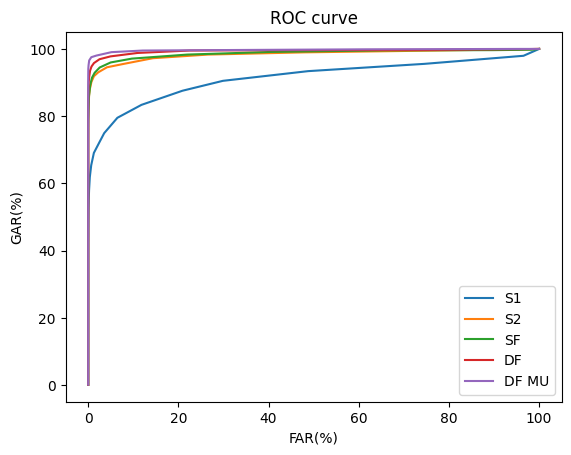

In [ ]:
fig, ax = plt.subplots()

line = ax.plot(FAR, 100-FRR, label='S1')
line2 = ax.plot(FAR2, 100-FRR2, label='S2')
line3 = ax.plot(FAR_sf, 100-FRR_sf, label='SF')
line4 = ax.plot(FAR_df, 100-FRR_df, label='DF')
line5 = ax.plot(FAR_dfmu,100-FRR_dfmu, label='DF MU')
ax.set(xlabel='FAR(%)', ylabel='GAR(%)',
       title='ROC curve')

ax.legend()
plt.show()